# DDPM Training on Google Colab
Complete implementation with GPU support

In [ ]:
# # Install dependencies
# import subprocess, sys
# packages = ['torch', 'torchvision', 'torchaudio', 'tqdm', 'numpy', 'matplotlib']
# for p in packages:
#     try:
#         __import__(p)
#         print(f'✓ {p} installed')
#     except:
#         print(f'Installing {p}...')
#         subprocess.check_call([sys.executable, '-m', 'pip', 'install', p, '-q'])
#         print(f'✓ {p} installed')

✓ torch installed
✓ torchvision installed
✓ torchaudio installed
✓ tqdm installed
✓ numpy installed
✓ matplotlib installed


In [ ]:
# !pip install

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import MNIST
import numpy as np
import math
from tqdm import tqdm
import matplotlib.pyplot as plt

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
torch.manual_seed(42)
np.random.seed(42)

Device: cuda
GPU: NVIDIA L4


In [ ]:
# Load MNIST
transforms_pipeline = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
dataset = MNIST(root='./mnist_data', train=True, download=True, transform=transforms_pipeline)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)
print(f'✓ Dataset loaded: {len(dataset)} images')

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.62MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 129kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.24MB/s]

✓ Dataset loaded: 60000 images


In [ ]:
# Diffusion utilities
def get_linear_schedule(n, start=0.0001, end=0.02):
    return torch.linspace(start, end, n)

def precompute_diffusion_constants(betas):
    alphas = 1 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    return alphas, alphas_cumprod, torch.sqrt(alphas_cumprod), torch.sqrt(1 - alphas_cumprod)

def sinusoidal_embedding(times, dim):
    half_dim = dim // 2
    freqs = torch.exp(torch.arange(half_dim, device=times.device, dtype=torch.float32) * -(math.log(10000.0) / (half_dim - 1)))
    args = times.view(-1, 1) * freqs.view(1, -1)
    return torch.cat([torch.sin(args), torch.cos(args)], dim=1)

In [ ]:
# Model components
class TimeAwareConv(nn.Module):
    def __init__(self, in_c, out_c, time_dim):
        super().__init__()
        self.conv1 = nn.Sequential(nn.Conv2d(in_c, out_c, 3, padding=1), nn.GroupNorm(32, out_c), nn.SiLU())
        self.time_proj = nn.Sequential(nn.SiLU(), nn.Linear(time_dim, out_c))
        self.conv2 = nn.Sequential(nn.Conv2d(out_c, out_c, 3, padding=1), nn.GroupNorm(32, out_c), nn.SiLU())
    def forward(self, x, t_emb):
        h = self.conv1(x)
        h = h + self.time_proj(t_emb)[:, :, None, None]
        return self.conv2(h)

class ResidualBlock(nn.Module):
    def __init__(self, in_c, out_c, time_dim):
        super().__init__()
        self.same = in_c == out_c
        self.conv = TimeAwareConv(in_c, out_c, time_dim)
        if not self.same:
            self.res = nn.Conv2d(in_c, out_c, 1)
    def forward(self, x, t):
        h = self.conv(x, t)
        return h + x if self.same else h + self.res(x)

In [ ]:
# DDPM UNet
class DDPMUNet(nn.Module):
    def __init__(self, in_c=1, out_c=1, time_dim=128, feat_dim=64):
        super().__init__()
        self.time_dim = time_dim
        self.time_emb = nn.Sequential(nn.Linear(time_dim, time_dim*2), nn.SiLU(), nn.Linear(time_dim*2, time_dim))
        self.init = nn.Conv2d(in_c, feat_dim, 3, padding=1)

        # Encoder
        self.down1_1 = ResidualBlock(feat_dim, feat_dim, time_dim)
        self.down1_2 = ResidualBlock(feat_dim, feat_dim, time_dim)
        self.down1_pool = nn.AvgPool2d(2)
        self.down2_1 = ResidualBlock(feat_dim, feat_dim*2, time_dim)
        self.down2_2 = ResidualBlock(feat_dim*2, feat_dim*2, time_dim)
        self.down2_pool = nn.AvgPool2d(2)
        self.down3_1 = ResidualBlock(feat_dim*2, feat_dim*4, time_dim)
        self.down3_2 = ResidualBlock(feat_dim*4, feat_dim*4, time_dim)

        # Decoder
        self.up = nn.Upsample(scale_factor=2, mode='nearest')
        self.up2_1 = ResidualBlock(feat_dim*6, feat_dim*2, time_dim)
        self.up2_2 = ResidualBlock(feat_dim*2, feat_dim*2, time_dim)
        self.up1_1 = ResidualBlock(feat_dim*3, feat_dim, time_dim)
        self.up1_2 = ResidualBlock(feat_dim, feat_dim, time_dim)
        self.final = nn.Sequential(nn.Conv2d(feat_dim, feat_dim, 3, padding=1), nn.SiLU(), nn.Conv2d(feat_dim, out_c, 1))

    def forward(self, x, t):
        t_e = self.time_emb(sinusoidal_embedding(t, self.time_dim))
        h = self.init(x)
        h1 = self.down1_1(h, t_e)
        h1 = self.down1_2(h1, t_e)
        skip1 = h1
        h1 = self.down1_pool(h1)
        h2 = self.down2_1(h1, t_e)
        h2 = self.down2_2(h2, t_e)
        skip2 = h2
        h2 = self.down2_pool(h2)
        h3 = self.down3_1(h2, t_e)
        h3 = self.down3_2(h3, t_e)
        h3 = self.up(h3)
        h3 = torch.cat([h3, skip2], dim=1)
        h3 = self.up2_1(h3, t_e)
        h3 = self.up2_2(h3, t_e)
        h3 = self.up(h3)
        h3 = torch.cat([h3, skip1], dim=1)
        h3 = self.up1_1(h3, t_e)
        h3 = self.up1_2(h3, t_e)
        return self.final(h3)

model = DDPMUNet().to(DEVICE)
print(f'✓ Model created: {sum(p.numel() for p in model.parameters()):,} parameters')

✓ Model created: 4,213,185 parameters


In [ ]:
# Training
num_steps = 1000
betas = get_linear_schedule(num_steps).to(DEVICE)
alphas, alphas_cumprod, sqrt_ac, sqrt_1_ac = precompute_diffusion_constants(betas)
alphas, alphas_cumprod, sqrt_ac, sqrt_1_ac = alphas.to(DEVICE), alphas_cumprod.to(DEVICE), sqrt_ac.to(DEVICE), sqrt_1_ac.to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
loss_history = []

# for epoch in tqdm(range(50), desc='Training'):
#     for x, _ in dataloader:
#         x = x.to(DEVICE)
#         t = torch.randint(0, num_steps, (x.size(0),), device=DEVICE)
#         eps = torch.randn_like(x)

#         sqrt_a = sqrt_ac[t].view(-1,1,1,1)
#         sqrt_1a = sqrt_1_ac[t].view(-1,1,1,1)
#         x_t = sqrt_a * x + sqrt_1a * eps

#         pred = model(x_t, t)
#         loss = F.mse_loss(pred, eps)

#         optimizer.zero_grad()
#         loss.backward()
#         torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
#         optimizer.step()

#         loss_history.append(loss.item())

# print('✓ Training complete!')
# torch.save(model.state_dict(), 'ddpm_model_50.pth')
# print('✓ Model saved')

In [ ]:
# #save model weights to drive
# from google.colab import drive
# drive.mount('/content/drive')
# torch.save(model.state_dict(), '/content/drive/MyDrive/ddpm_model_50.pth')
# print('✓ Model saved to Google Drive')

In [ ]:
!pip install -q torchmetrics[image]
!pip install -q torch-fidelity

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 63.6 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls

drive  mnist_data  sample_data


In [ ]:
!ls


drive  mnist_data  sample_data


In [ ]:
model= DDPMUNet().to(DEVICE)
model.load_state_dict(torch.load('/content/drive/MyDrive/ddpm_model_50.pth', map_location=DEVICE))

<All keys matched successfully>

In [ ]:
# # Visualize loss
# plt.figure(figsize=(12, 5))
# plt.plot(loss_history)
# plt.xlabel('Iteration')
# plt.ylabel('Loss')
# plt.title('DDPM Training Loss')
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()
# print(f'Initial loss: {loss_history[0]:.4f}')
# print(f'Final loss: {loss_history[-1]:.4f}')

In [ ]:
# Generation function with reverse diffusion
@torch.no_grad()
def generate_samples(model, num_samples, num_steps, img_size=28, batch_size=64):
    """Generate samples from noise using reverse diffusion process"""
    model.eval()

    betas = get_linear_schedule(num_steps).to(DEVICE)
    alphas, alphas_cumprod, sqrt_ac, sqrt_1_ac = precompute_diffusion_constants(betas)
    alphas, alphas_cumprod, sqrt_ac, sqrt_1_ac = alphas.to(DEVICE), alphas_cumprod.to(DEVICE), sqrt_ac.to(DEVICE), sqrt_1_ac.to(DEVICE)

    # Posterior variance
    posterior_var = (1 - alphas_cumprod[:-1]) / (1 - alphas_cumprod[1:]) * betas[1:]

    generated_samples = []
    num_batches = (num_samples + batch_size - 1) // batch_size

    for batch_idx in tqdm(range(num_batches), desc='Generating batches'):
        current_batch_size = min(batch_size, num_samples - batch_idx * batch_size)
        x_t = torch.randn(current_batch_size, 1, img_size, img_size, device=DEVICE)

        for t in tqdm(range(num_steps-1, -1, -1), desc=f'Batch {batch_idx+1}/{num_batches}', leave=False):
            t_tensor = torch.full((current_batch_size,), t, dtype=torch.long, device=DEVICE)
            pred_noise = model(x_t, t_tensor)

            alpha_t = alphas[t]
            alpha_cumprod_t = alphas_cumprod[t]

            mean = (1.0 / torch.sqrt(alpha_t)) * (x_t - (betas[t] / torch.sqrt(1.0 - alpha_cumprod_t)) * pred_noise)

            if t > 0:
                z = torch.randn_like(x_t)
                x_t = mean + torch.sqrt(posterior_var[t-1]) * z
            else:
                x_t = mean

        x_t = torch.clamp(x_t, -1, 1)
        generated_samples.append(x_t.cpu())

    return torch.cat(generated_samples, dim=0)

# Generate samples
print('Generating 500 samples for evaluation...')
generated = generate_samples(model, 500, num_steps, img_size=28)
print(f'✓ Generated shape: {generated.shape}')


Generating 500 samples for evaluation...


Generating batches: 100%|██████████| 8/8 [01:05<00:00,  8.19s/it]

✓ Generated shape: torch.Size([500, 1, 28, 28])


Processing real images for FID...
Processing generated images for FID...
✓ FID Score: 0.0055


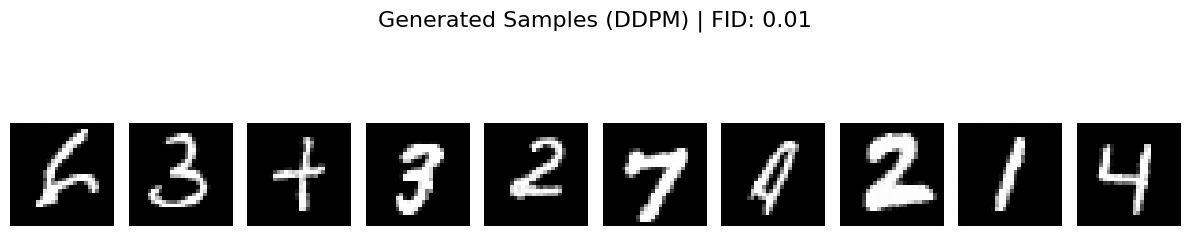

In [ ]:
import torch
import matplotlib.pyplot as plt
from torchmetrics.image.fid import FrechetInceptionDistance

# --- 1. Setup Metrics ---
# feature=64 is faster/lighter; use feature=2048 for standard academic FID comparison
fid_metric = FrechetInceptionDistance(feature=64, normalize=True).to(DEVICE)

# --- 2. Process Real Images (Baseline) ---
# We need to feed real images to the metric.
# Assuming you have a 'dataloader' or 'train_loader' available.
print("Processing real images for FID...")
real_images_count = 0
for batch in dataloader: # <--- Make sure this is your actual dataloader
    # Unpack batch (handle cases where dataloader returns (img, label) or just img)
    real_imgs = batch[0] if isinstance(batch, list) else batch
    real_imgs = real_imgs.to(DEVICE)

    # Preprocessing:
    # 1. Convert [-1, 1] to [0, 1] if your real data is normalized to -1,1
    # If your dataloader returns [0, 1], skip the next line.
    real_imgs = (real_imgs + 1) / 2

    # 2. Expand to 3 channels (N, 1, H, W) -> (N, 3, H, W) for Inception
    if real_imgs.shape[1] == 1:
        real_imgs = real_imgs.repeat(1, 3, 1, 1)

    fid_metric.update(real_imgs, real=True)

    real_images_count += real_imgs.size(0)
    # Don't need to process the whole dataset if it's huge,
    # but usually 500-2k samples are good for stability.
    if real_images_count >= 500:
        break

# --- 3. Process Generated Images (Fake) ---
print("Processing generated images for FID...")

# Your generated samples are currently on CPU and range [-1, 1]
fake_imgs = generated.to(DEVICE)

# Preprocessing:
# 1. Convert [-1, 1] to [0, 1]
fake_imgs = (fake_imgs + 1) / 2

# 2. Expand to 3 channels
if fake_imgs.shape[1] == 1:
    fake_imgs = fake_imgs.repeat(1, 3, 1, 1)

fid_metric.update(fake_imgs, real=False)

# --- 4. Compute Metric ---
fid_score = fid_metric.compute().item()
print(f"✓ FID Score: {fid_score:.4f}")

# --- 5. Visualization with FID ---
fig, axs = plt.subplots(1, 10, figsize=(12, 3))
for i, ax in enumerate(axs.flatten()):
    if i < len(generated):
        # Squeeze to remove channel dim for grayscale plotting
        ax.imshow(generated[i].squeeze().cpu().numpy(), cmap='gray')
    ax.axis('off')

plt.tight_layout()
# Add the FID score to the title
plt.suptitle(f'Generated Samples (DDPM) | FID: {fid_score:.2f}', y=1.05, fontsize=16)
plt.show()

2. Generated samples with DDPM (Standard Diffusion)

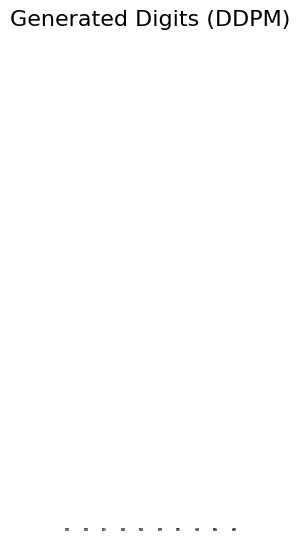

In [ ]:
fig, axs = plt.subplots(1, 10, figsize=(8, 8))
for i, ax in enumerate(axs.flatten()):
    ax.imshow(generated[i].squeeze().cpu().numpy(), cmap='gray')
    ax.axis('off')
plt.tight_layout()
plt.suptitle('Generated Samples (DDPM)', y=1.02, fontsize=16)
plt.show()

1.Trained std DDPM diffusion





DDIM Sampling: 100%|██████████| 50/50 [00:00<00:00, 113.81it/s]


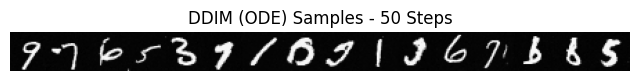

In [ ]:
# Sample using ODE
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt

# Load trained model weights from Google Drive
model.load_state_dict(torch.load('/content/drive/MyDrive/ddpm_model_50.pth', map_location=DEVICE))
model.to(DEVICE)

@torch.no_grad()
def ddim_sample(model, num_samples, num_steps=None, img_size=28, device=None, eta=0.0, custom_schedule=None):
    """
    DDIM Sampler with support for Custom AYS Schedules.

    Args:
        model: The trained UNet model
        num_samples: Number of images to generate
        num_steps: Number of steps (ignored if custom_schedule is provided)
        img_size: Dimension of image
        device: Torch device
        eta: Control for stochasticity (0.0 = ODE)
        custom_schedule: List/Tensor of time steps [T, ..., 0] (e.g., from AYS)
    """
    if device is None:
        device = next(model.parameters()).device

    model.eval()

    # --- 1. Schedule Setup ---
    training_steps = 1000

    if custom_schedule is not None:
        # Use the optimized AYS schedule
        times = torch.tensor(custom_schedule, device=device, dtype=torch.long)
    else:
        # Fallback to standard uniform schedule
        if num_steps is None: num_steps = 50
        times = torch.linspace(0, training_steps - 1, steps=num_steps + 1).long().to(device)
        times = torch.flip(times, [0]) # Ensure T -> 0

    # Create pairs for the loop: (t_curr, t_prev)
    # e.g., if times = [999, 800, 0], pairs = [(999, 800), (800, 0)]
    time_pairs = list(zip(times[:-1], times[1:]))

    # --- 2. Precompute Alphas ---
    betas = torch.linspace(0.0001, 0.02, training_steps).to(device)
    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)

    # --- 3. Initial Noise ---
    x = torch.randn(num_samples, 1, img_size, img_size, device=device)

    # --- 4. Sampling Loop ---
    for t_curr, t_prev in tqdm(time_pairs, desc="DDIM Sampling"):
        # Create batch of time embeddings
        t_batch = torch.full((num_samples,), t_curr, device=device, dtype=torch.long)

        # Predict noise
        pred_noise = model(x, t_batch)

        # Get alpha values
        alpha_t = alphas_cumprod[t_curr]
        alpha_t_prev = alphas_cumprod[t_prev] if t_prev >= 0 else torch.tensor(1.0).to(device)

        # DDIM Update (ODE Step)
        pred_x0 = (x - torch.sqrt(1 - alpha_t) * pred_noise) / torch.sqrt(alpha_t)
        pred_x0 = torch.clamp(pred_x0, -1, 1)

        sigma_t = eta * torch.sqrt((1 - alpha_t_prev) / (1 - alpha_t) * (1 - alpha_t / alpha_t_prev))
        dir_xt = torch.sqrt(1 - alpha_t_prev - sigma_t**2) * pred_noise
        noise = torch.randn_like(x) if eta > 0 else 0.

        x = torch.sqrt(alpha_t_prev) * pred_x0 + dir_xt + sigma_t * noise

    return x

# --- Usage Example ---
# Assuming 'model' is your loaded DDPMUNet
# Sample using 50 steps (faster!) instead of the original 1000
ode_samples = ddim_sample(model, num_samples=16, num_steps=50, eta=0.0)

# Visualize
plt.figure(figsize=(8,8))
plt.imshow(torch.cat([s for s in ode_samples], dim=2).squeeze().cpu(), cmap='gray')
plt.axis('off')
plt.title("DDIM (ODE) Samples - 50 Steps")
plt.show()

In [ ]:
# AYS implementation
import torch
import numpy as np
import copy

def get_alphas(training_steps, device):
    """Retrieve pre-computed alphas for the noise schedule."""
    betas = torch.linspace(0.0001, 0.02, training_steps).to(device)
    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    return alphas_cumprod

@torch.no_grad()
def measure_interval_error(model, t_start, t_end, alphas_cumprod, num_samples=128):
    """
    Estimates the 'curvature' (KLUB error) within a specific time interval [t_end, t_start].
    Note: t_start is the higher number (earlier in diffusion), t_end is lower.
    """
    device = next(model.parameters()).device

    # 1. Sample random times 'tau' inside this interval
    # We check how much the model deviates at these random points
    taus = torch.randint(t_end, t_start + 1, (num_samples,), device=device)

    # 2. Create corresponding t_start batch for comparison
    t_starts = torch.full((num_samples,), t_start, dtype=torch.long, device=device)

    # 3. Create x_0 (clean data) to generate consistent x_t
    # In AYS, we compare outputs given the SAME path.
    img_size = 28 # MNIST size
    x0 = torch.randn(num_samples, 1, img_size, img_size, device=device) # Actually should be real data, but noise is fine for curvature est.
    # ideally x0 is sampled from real data, let's use random noise as proxy for structure
    # or better: pass a real batch if available. For this snippet, we use gaussian approx.

    # 4. Noise x0 to t_start and tau
    # We need to compare Model(x_tau) vs Model(x_start)
    # Crucially, they must be on the SAME trajectory.
    # So we use the same epsilon for both noise additions.
    noise = torch.randn_like(x0)

    def get_xt(x0, t, noise):
        alpha_t = alphas_cumprod[t].view(-1, 1, 1, 1)
        return torch.sqrt(alpha_t) * x0 + torch.sqrt(1 - alpha_t) * noise

    x_tau = get_xt(x0, taus, noise)
    x_start = get_xt(x0, t_starts, noise)

    # 5. Get Model Predictions
    # AYS objective: minimize || D(x_tau) - D(x_start) ||^2
    # For DDPM, epsilon prediction is equivalent to D (denoiser) prediction
    eps_tau = model(x_tau, taus)
    eps_start = model(x_start, t_starts)

    # 6. Compute MSE (proxy for KL divergence)
    # This measures how much the "vector field" changed inside the step
    error = torch.mean((eps_tau - eps_start)**2)
    return error.item()

def optimize_schedule(model, steps=10, training_steps=1000):
    """
    Runs the AYS greedy optimization to find the best time steps.
    """
    device = next(model.parameters()).device
    model.eval()
    alphas = get_alphas(training_steps, device)

    # 1. Initialize with Uniform Schedule
    # e.g. [999, 899, ..., 0]
    schedule = torch.linspace(training_steps - 1, 0, steps + 1).long().tolist()
    print(f"Initial Schedule: {schedule}")

    # 2. Optimization Loop (Greedy Search)
    # We iterate a few times to settle on a stable schedule
    for iteration in range(5):
        print(f"--- Optimization Pass {iteration + 1} ---")
        changes_made = False

        # Iterate through internal points (exclude first 999 and last 0)
        for i in range(1, steps):
            t_prev = schedule[i-1] # Higher bound
            t_curr = schedule[i]   # Current point to optimize
            t_next = schedule[i+1] # Lower bound

            best_t = t_curr
            best_error = float('inf')

            # Search neighborhood (e.g., +/- 20 steps)
            # We want to find a t_new between t_prev and t_next
            search_range = range(t_next + 1, t_prev, 5) # Step size 5 for speed

            # We must minimize sum of errors of the two adjacent intervals:
            # Error(Prev -> Curr) + Error(Curr -> Next)

            for t_candidate in search_range:
                # Error if we put the step here
                err_upper = measure_interval_error(model, t_prev, t_candidate, alphas)
                err_lower = measure_interval_error(model, t_candidate, t_next, alphas)
                total_err = err_upper + err_lower

                if total_err < best_error:
                    best_error = total_err
                    best_t = t_candidate

            if best_t != t_curr:
                schedule[i] = best_t
                changes_made = True

        print(f"Current Schedule: {schedule}")
        if not changes_made:
            print("Converged!")
            break

    return schedule

# --- Usage ---
# Run this block to get your optimized list
# Note: 'model' must be the loaded DDPMUNet from the previous step
optimal_schedule = optimize_schedule(model, steps=10) # Try 10 steps for speed

Initial Schedule: [999, 899, 799, 699, 599, 499, 399, 299, 199, 99, 0]
--- Optimization Pass 1 ---
Current Schedule: [999, 850, 765, 640, 575, 455, 360, 285, 150, 71, 0]
--- Optimization Pass 2 ---
Current Schedule: [999, 821, 716, 621, 491, 426, 351, 211, 122, 46, 0]
--- Optimization Pass 3 ---
Current Schedule: [999, 762, 662, 557, 472, 397, 272, 193, 112, 61, 0]
--- Optimization Pass 4 ---
Current Schedule: [999, 713, 628, 538, 448, 338, 264, 178, 107, 71, 0]
--- Optimization Pass 5 ---
Current Schedule: [999, 704, 599, 509, 424, 325, 209, 153, 102, 56, 0]


/tmp/ipython-input-3502809858.py:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  times = torch.tensor(custom_schedule, device=device, dtype=torch.long)
DDIM Sampling: 100%|██████████| 10/10 [00:00<00:00, 164.89it/s]


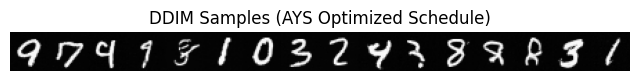

In [ ]:
# Instead of linspace, we use the specific optimized times
times = torch.tensor(optimal_schedule).to(DEVICE)
# Run sampling
custom_schedule_samples = ddim_sample(model, num_samples=16, num_steps=len(optimal_schedule)-1, eta=0.0, custom_schedule=times) # You would modify ddim_sample to accept this list

# Visualize custom schedule samples
plt.figure(figsize=(8,8))
plt.imshow(torch.cat([s for s in custom_schedule_samples], dim=2).squeeze().cpu(), cmap='gray')
plt.axis('off')
plt.title("DDIM Samples (AYS Optimized Schedule)")
plt.show()


--- Training AYS Student ---
Training on schedule (Uniform Weights): [999, 689, 604, 524, 394, 285, 204, 158, 112, 61, 0]
Epoch 5/20 | Avg Loss: 0.05431
Epoch 10/20 | Avg Loss: 0.05460
Epoch 15/20 | Avg Loss: 0.05816
Epoch 20/20 | Avg Loss: 0.05741

--- Training Uniform Student ---
Training on schedule (Uniform Weights): [999, 899, 799, 699, 599, 499, 399, 299, 199, 99, 0]
Epoch 5/20 | Avg Loss: 0.06455
Epoch 10/20 | Avg Loss: 0.07467
Epoch 15/20 | Avg Loss: 0.06855
Epoch 20/20 | Avg Loss: 0.06788

Generating Single-Step Samples...


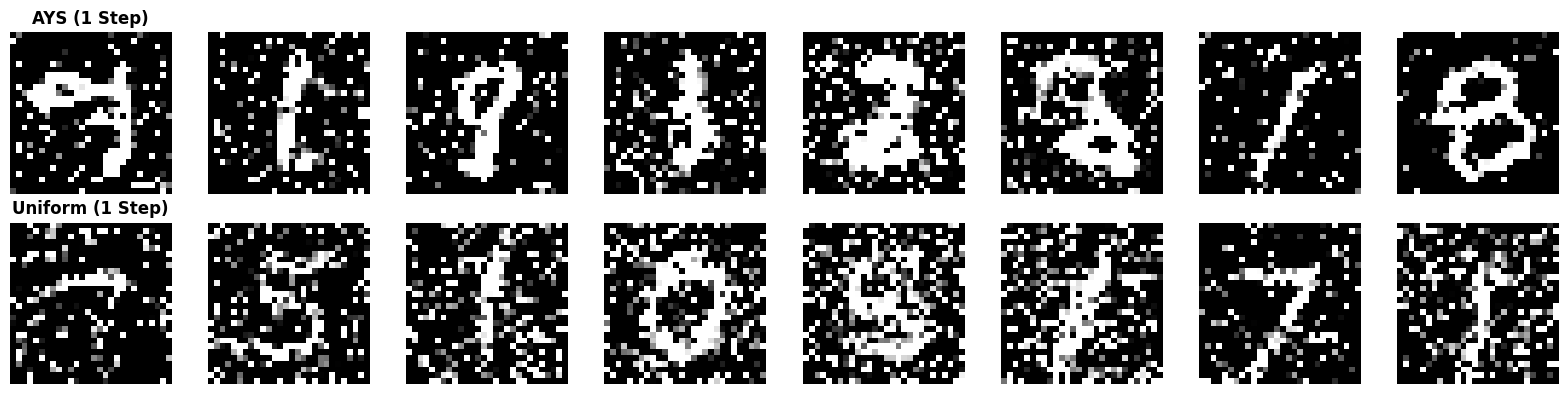

In [ ]:
# TODO do this for 5 steps
import copy
import torch.nn.functional as F

def robust_consistency_loss(student, student_ema, teacher, x, t_n1, t_n):
    device = x.device
    noise = torch.randn_like(x)

    def get_alpha(t_idx):
        return alphas_cumprod[t_idx].view(-1, 1, 1, 1)

    alpha_n1 = get_alpha(t_n1)
    x_tn1 = torch.sqrt(alpha_n1) * x + torch.sqrt(1 - alpha_n1) * noise

    # --- Student Prediction ---
    student_eps = student(x_tn1, t_n1)
    student_x0 = (x_tn1 - torch.sqrt(1 - alpha_n1) * student_eps) / torch.sqrt(alpha_n1)
    student_x0 = torch.clamp(student_x0, -1.0, 1.0)

    # --- Teacher Step ---
    with torch.no_grad():
        teacher_eps = teacher(x_tn1, t_n1)
        teacher_x0 = (x_tn1 - torch.sqrt(1 - alpha_n1) * teacher_eps) / torch.sqrt(alpha_n1)
        teacher_x0 = torch.clamp(teacher_x0, -1.0, 1.0)

        alpha_n = get_alpha(t_n)
        dir_xt = torch.sqrt(1 - alpha_n) * teacher_eps
        x_tn_hat = torch.sqrt(alpha_n) * teacher_x0 + dir_xt

    # --- Target ---
    with torch.no_grad():
        if t_n[0] == 0:
            target_x0 = x_tn_hat
        else:
            target_eps = student_ema(x_tn_hat, t_n)
            target_x0 = (x_tn_hat - torch.sqrt(1 - alpha_n) * target_eps) / torch.sqrt(alpha_n)

        target_x0 = torch.clamp(target_x0, -1.0, 1.0)

    # --- FIX: Uniform Weighting ---
    # We removed 'weights = alpha_n1'
    # Now the model will actually learn the high-noise steps.
    loss = F.mse_loss(student_x0, target_x0)

    return loss

# 1. Update the training loop to use the new loss function logic
# (We just redefine the function here for clarity, Python will use the latest definition)
def train_consistency_robust(teacher_model, schedule, num_epochs=20):
    device = next(teacher_model.parameters()).device
    student = copy.deepcopy(teacher_model)
    student.train()
    student_ema = copy.deepcopy(teacher_model)
    student_ema.eval()

    # Increased LR slightly since we have clamping protection
    optimizer = torch.optim.AdamW(student.parameters(), lr=1e-4)
    schedule_tensor = torch.tensor(schedule, device=device, dtype=torch.long)

    print(f"Training on schedule (Uniform Weights): {schedule}")

    for epoch in range(num_epochs):
        epoch_loss = 0
        for x, _ in dataloader:
            x = x.to(device)
            indices = torch.randint(0, len(schedule_tensor) - 1, (x.size(0),), device=device)
            t_n1 = schedule_tensor[indices]
            t_n = schedule_tensor[indices + 1]

            loss = robust_consistency_loss(student, student_ema, teacher_model, x, t_n1, t_n)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            mu = 0.999
            for p, p_ema in zip(student.parameters(), student_ema.parameters()):
                p_ema.data.mul_(mu).add_(p.data, alpha=1 - mu)

            epoch_loss += loss.item()
        # Print less frequently to reduce clutter
        if (epoch+1) % 5 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} | Avg Loss: {epoch_loss / len(dataloader):.5f}")

    return student

# 2. Define Schedules
ays_schedule = [999, 689, 604, 524, 394, 285, 204, 158, 112, 61, 0]
uniform_schedule = torch.linspace(999, 0, 11).long().tolist()

# 3. Train
print("\n--- Training AYS Student ---")
student_ays = train_consistency_robust(model, ays_schedule, num_epochs=20)

print("\n--- Training Uniform Student ---")
student_uniform = train_consistency_robust(model, uniform_schedule, num_epochs=20)

# 4. Compare
print("\nGenerating Single-Step Samples...")
samples_ays = consistency_sample(student_ays, num_samples=8)
samples_uniform = consistency_sample(student_uniform, num_samples=8)

fig, axs = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axs[0, i].imshow(samples_ays[i].cpu().squeeze(), cmap='gray')
    axs[0, i].axis('off')
    if i == 0: axs[0, i].set_title("AYS (1 Step)", fontweight="bold")

    axs[1, i].imshow(samples_uniform[i].cpu().squeeze(), cmap='gray')
    axs[1, i].axis('off')
    if i == 0: axs[1, i].set_title("Uniform (1 Step)", fontweight="bold")

plt.tight_layout()
plt.show()
@torch.no_grad()
def consistency_sample(model, num_samples, img_size=28, device=None):
    """
    Generates images in exactly ONE step (Consistency Property).
    """
    if device is None:
        device = next(model.parameters()).device

    model.eval()

    # 1. Start from pure Gaussian noise (x_T)
    x_T = torch.randn(num_samples, 1, img_size, img_size, device=device)

    # 2. Define T_max (e.g., 999 or whatever your max training step was)
    # The model maps (x_T, T) -> x_0 directly
    t_batch = torch.full((num_samples,), 999, device=device, dtype=torch.long)

    # 3. One forward pass
    pred_noise = model(x_T, t_batch)

    # 4. Convert epsilon to x_0
    # We need alpha_cumprod[999]
    # (Assuming you have access to alphas_cumprod globally or pass it in)
    alpha_T = alphas_cumprod[999]

    pred_x0 = (x_T - torch.sqrt(1 - alpha_T) * pred_noise) / torch.sqrt(alpha_T)
    pred_x0 = torch.clamp(pred_x0, -1, 1)

    return pred_x0

Verifying Teacher with AYS Schedule...


DDIM Sampling: 100%|██████████| 10/10 [00:00<00:00, 118.44it/s]


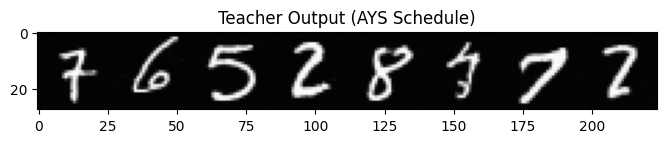

In [ ]:
# Generate samples using the Teacher (DDPM) and the AYS schedule
print("Verifying Teacher with AYS Schedule...")
teacher_samples = ddim_sample(model, num_samples=8, custom_schedule=optimal_schedule)

plt.figure(figsize=(8,2))
plt.imshow(torch.cat([s for s in teacher_samples], dim=2).squeeze().cpu(), cmap='gray')
plt.title("Teacher Output (AYS Schedule)")
plt.show()


--- Training AYS Student ---
Training on schedule: [999, 689, 604, 524, 394, 285, 204, 158, 112, 61, 0]
Epoch 1/20 | Avg Loss: 0.00702
Epoch 2/20 | Avg Loss: 0.00627
Epoch 3/20 | Avg Loss: 0.00681
Epoch 4/20 | Avg Loss: 0.00596
Epoch 5/20 | Avg Loss: 0.00706
Epoch 6/20 | Avg Loss: 0.00771
Epoch 7/20 | Avg Loss: 0.00653
Epoch 8/20 | Avg Loss: 0.00667
Epoch 9/20 | Avg Loss: 0.00679
Epoch 10/20 | Avg Loss: 0.00637
Epoch 11/20 | Avg Loss: 0.00699
Epoch 12/20 | Avg Loss: 0.00602
Epoch 13/20 | Avg Loss: 0.00658
Epoch 14/20 | Avg Loss: 0.00726
Epoch 15/20 | Avg Loss: 0.00652
Epoch 16/20 | Avg Loss: 0.00629
Epoch 17/20 | Avg Loss: 0.00762
Epoch 18/20 | Avg Loss: 0.00790
Epoch 19/20 | Avg Loss: 0.00716
Epoch 20/20 | Avg Loss: 0.00673

--- Training Uniform Student ---
Training on schedule: [999, 899, 799, 699, 599, 499, 399, 299, 199, 99, 0]
Epoch 1/20 | Avg Loss: 0.00672
Epoch 2/20 | Avg Loss: 0.00535
Epoch 3/20 | Avg Loss: 0.00629
Epoch 4/20 | Avg Loss: 0.00624
Epoch 5/20 | Avg Loss: 0.00578


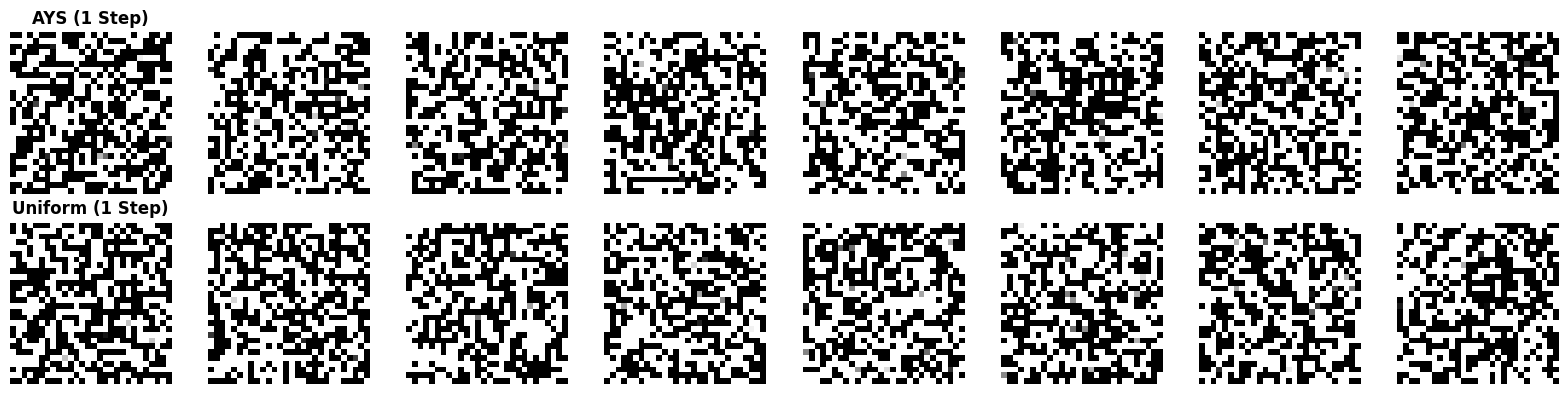

In [ ]:
# 1. Define Schedules
# AYS Schedule (Using the output you found in your previous optimization step)
ays_schedule = [999, 689, 604, 524, 394, 285, 204, 158, 112, 61, 0]
# Uniform Schedule (Baseline)
uniform_schedule = torch.linspace(999, 0, 11).long().tolist()

print(f"AYS Schedule: {ays_schedule}")
print(f"Uniform Schedule: {uniform_schedule}")

# 2. Train Two Student Models
# We use 'train_consistency_robust' which you defined in your notebook
print("\n--- Training AYS Student ---")
# Note: In real research, we'd train for more epochs, but 10-20 is good for a demo
student_ays = train_consistency_robust(model, ays_schedule, num_epochs=20)

print("\n--- Training Uniform Student ---")
student_uniform = train_consistency_robust(model, uniform_schedule, num_epochs=20)

# 3. Single-Step Generation
print("\nGenerating Single-Step Samples...")
# The consistency model is designed to map x_T (noise) -> x_0 (image) in ONE step.
samples_ays = consistency_sample(student_ays, num_samples=8)
samples_uniform = consistency_sample(student_uniform, num_samples=8)

# 4. Visualization Side-by-Side
fig, axs = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    # Top Row: AYS Samples
    axs[0, i].imshow(samples_ays[i].cpu().squeeze(), cmap='gray')
    axs[0, i].axis('off')
    if i == 0: axs[0, i].set_title("AYS (1 Step)", fontweight="bold")

    # Bottom Row: Uniform Samples
    axs[1, i].imshow(samples_uniform[i].cpu().squeeze(), cmap='gray')
    axs[1, i].axis('off')
    if i == 0: axs[1, i].set_title("Uniform (1 Step)", fontweight="bold")

plt.tight_layout()
plt.show()

In [ ]:
# 1. Generate Schedules
ays_schedule = optimize_schedule(model, steps=10)
uniform_schedule = torch.linspace(999, 0, 11).long().tolist()

print(f"AYS Schedule: {ays_schedule}")
print(f"Uniform Schedule: {uniform_schedule}")

# 2. Train Two Models
print("--- Training AYS Student ---")
student_ays = train_consistency_ays(model, ays_schedule, num_epochs=5)

print("--- Training Uniform Student ---")
student_uniform = train_consistency_ays(model, uniform_schedule, num_epochs=5)

# 3. Compare Single-Step Generation
samples_ays = consistency_sample(student_ays, num_samples=8)
samples_uniform = consistency_sample(student_uniform, num_samples=8)

# 4. Visualize Side-by-Side
fig, axs = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    # Top Row: AYS
    axs[0, i].imshow(samples_ays[i].cpu().squeeze(), cmap='gray')
    axs[0, i].axis('off')
    if i == 0: axs[0, i].set_title("AYS (1 Step)")

    # Bottom Row: Uniform
    axs[1, i].imshow(samples_uniform[i].cpu().squeeze(), cmap='gray')
    axs[1, i].axis('off')
    if i == 0: axs[1, i].set_title("Uniform (1 Step)")

plt.show()

Initial Schedule: [999, 899, 799, 699, 599, 499, 399, 299, 199, 99, 0]
--- Optimization Pass 1 ---
Current Schedule: [999, 835, 745, 640, 550, 465, 355, 265, 175, 101, 0]
--- Optimization Pass 2 ---
Current Schedule: [999, 841, 681, 596, 531, 411, 331, 226, 167, 61, 0]
--- Optimization Pass 3 ---
Current Schedule: [999, 732, 642, 572, 477, 417, 292, 233, 122, 71, 0]
--- Optimization Pass 4 ---
Current Schedule: [999, 673, 618, 533, 473, 373, 279, 168, 112, 61, 0]
--- Optimization Pass 5 ---
Current Schedule: [999, 669, 584, 534, 454, 375, 254, 173, 107, 46, 0]
AYS Schedule: [999, 669, 584, 534, 454, 375, 254, 173, 107, 46, 0]
Uniform Schedule: [999, 899, 799, 699, 599, 499, 399, 299, 199, 99, 0]
--- Training AYS Student ---
Starting CD Training on schedule: [999, 669, 584, 534, 454, 375, 254, 173, 107, 46, 0]
Epoch 1 Loss: 0.0006
Epoch 2 Loss: 0.0004
Epoch 3 Loss: 0.0002
Epoch 4 Loss: 0.0002
Epoch 5 Loss: 0.0003
--- Training Uniform Student ---
Starting CD Training on schedule: [999, 8

KeyboardInterrupt: 

# Task
Calculate and display the Frechet Inception Distance (FID) score between generated images and real images, and update the visualization to include the calculated FID score.

## Install torchmetrics

### Subtask:
Install the `torchmetrics` library.


**Reasoning**:
The subtask is to install the `torchmetrics` library. I will use `!pip install torchmetrics` in a new code cell to achieve this.

